# Kidney Cancer Prediction - Random Forest Baseline
This notebook runs the exact same preprocessing and training split as the PyTorch CNN exploratory notebook, preparing the target 3D arrays to act as flattened 1D features for a `RandomForestClassifier`.

In [2]:
import os
import parse_labels
import dataset
import util

import importlib
import torch
import numpy as np

importlib.reload(parse_labels)

# gets the labels
base_path = os.getcwd()
input_path = "raw_data/manifest-xxn3N2Qq630907925598003437/TCGA-KIRC"
all_dirs = os.listdir(input_path)


label_path = os.path.join(base_path, "raw_data", "labels.txt")
data_path = os.path.join(base_path, "raw_data", "manifest-xxn3N2Qq630907925598003437/TCGA-KIRC")

map = parse_labels.get_all_dcm_files(label_path, data_path)

In [3]:
# Get patient scan series data (grouped by patient AND scan series)
series_data = parse_labels.get_all_dcm_files(label_path, data_path)
print(f"Found {len(series_data)} scan series total\n")

Found 2652 scan series total



In [4]:
importlib.reload(util)
import math
# Preload scan series volumes into memory

DATA_SHAPE = (64, 192, 192)
print("Preloading scan series volumes...")
preloaded_data = util.preload_dcm_files(
    series_data, 
    crop=(100 * (1 - 1/math.sqrt(2)), 100 * (1 - 1/math.sqrt(2)), 0),
    target_shape=DATA_SHAPE,  # (Depth, Height, Width)
    max_files=None   # Start with small subset to test
)
print(f"Successfully preloaded {len(preloaded_data)} scan series volumes")


# Print grade count for each label
grade_counts = {}
for _, label, _ in preloaded_data.values():
    lbl = label.item()
    grade_counts[lbl] = grade_counts.get(lbl, 0) + 1

print("\nGrade count by label:")
for lbl in sorted(grade_counts.keys()):
    print(f"  Label {lbl} (Grade {lbl + 1}): {grade_counts[lbl]} samples")

Preloading scan series volumes...


Preloading Scan Series:  71%|███████   | 1883/2652 [12:18<05:01,  2.55series/s]

Successfully preloaded 1883 scan series volumes

Grade count by label:
  Label 0 (Grade 1): 16 samples
  Label 1 (Grade 2): 787 samples
  Label 2 (Grade 3): 788 samples
  Label 3 (Grade 4): 292 samples


In [3]:
from skimage import exposure
from scipy.ndimage import laplace
from tqdm import tqdm
import os

# Process each scan volume
for key, (volume, label, patient_id) in tqdm(preloaded_data.items(), desc="Processing scan volumes"):
    # Extract top-left 3x3x3 cube and compute average brightness
    cube = volume[0, 0:3, 0:3, 0:3]
    avg_brightness = torch.mean(cube).item()
    
    # Invert if average brightness > 128
    if avg_brightness >= 128:
        volume = 256 - volume
    
    processed_volume = volume.float()
    
    # Normalize to 0-1 range for skimage processing
    if processed_volume.max() > 0:
        processed_volume = processed_volume / processed_volume.max()
    
    # Convert to numpy and remove channel dimension [1, D, H, W] -> [D, H, W]
    processed_volume_np = processed_volume[0].cpu().numpy()
    
    # 1. Laplacian Sharpening
    lap = laplace(processed_volume_np)
    sharpened_volume = processed_volume_np - 0.3 * lap
    
    # 2. Histogram Equalization
    equalized_volume = exposure.equalize_hist(sharpened_volume)
    
    # Add the channel dimension back
    final_volume_np = np.expand_dims(equalized_volume, axis=0)
    
    # Convert back to tensor and 0-255 range
    final_volume = torch.from_numpy(final_volume_np).float() * 255
    preloaded_data[key] = (final_volume, label, patient_id)

# Save the preprocessed data directly
save_path = os.path.join(base_path, "preloaded_data_processed_rf.pt")
print(f"Saving preprocessed data to {save_path}...")
torch.save(preloaded_data, save_path)
print("Data successfully saved.")

NameError: name 'preloaded_data' is not defined

In [4]:
load_path = os.path.join(base_path, "preloaded_data_processed_rf.pt")
print(f"Loading preprocessed data from {load_path}...")
preloaded_data = torch.load(load_path)


Loading preprocessed data from /home/petedowney/github/KidneyCancerPrediction/preloaded_data_processed_rf.pt...


/tmp/ipykernel_4160/430038296.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  preloaded_data = torch.load(load_path)


In [9]:
importlib.reload(dataset)
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import numpy as np

def augment_data(data_dict, series_dict):
    counts = {}
    for _, label, _ in data_dict.values():
        lbl = label.item()
        counts[lbl] = counts.get(lbl, 0) + 1

    target_count = max(counts.values())
    print(f"Augmenting minority labels to target count: {target_count}")

    aug_data = data_dict.copy()
    aug_series = series_dict.copy()
    
    new_idx = max(data_dict.keys()) + 1 if data_dict else 0

    for label_to_augment, current_count in counts.items():
        if label_to_augment == 0:
            continue

        if current_count < target_count:
            needed = target_count - current_count
            class_keys = [k for k, v in data_dict.items() if v[1].item() == label_to_augment]

            augmented_keys = np.random.choice(class_keys, size=needed, replace=True)

            for aug_key in augmented_keys:
                volume, label, patient_id = data_dict[aug_key]
                aug_data[new_idx] = (volume, label, f"{patient_id}_aug")
                if aug_key in series_dict:
                    aug_series[new_idx] = series_dict[aug_key]
                new_idx += 1

    return aug_data, aug_series

def print_label_distribution(y_arr, title="Label distribution"):
    counts = {}
    for lbl in y_arr:
        counts[lbl] = counts.get(lbl, 0) + 1
    print(f"{title}:")
    for lbl in sorted(counts.keys()):
        print(f"  Label {lbl} (Grade {lbl + 1}): {counts[lbl]} samples")

to_uint8_data = {}
for key, (vol, lbl, pid) in preloaded_data.items():
    uint8_vol = (vol * 255).to(torch.uint8)
    to_uint8_data[key] = (uint8_vol, lbl, pid)

keys = list(to_uint8_data.keys())
series_items = [(k, series_data[k]) for k in keys]
data_items = [(k, to_uint8_data[k]) for k in keys]

# 60 / 20 / 20 split
train_series_items, temp_series_items, train_data_items, temp_data_items = train_test_split(
    series_items, data_items, test_size=0.4, random_state=42
)
val_series_items, test_series_items, val_data_items, test_data_items = train_test_split(
    temp_series_items, temp_data_items, test_size=0.5, random_state=43
)

train_series = {i: item[1] for i, item in enumerate(train_series_items)}
val_series = {i: item[1] for i, item in enumerate(val_series_items)}
test_series = {i: item[1] for i, item in enumerate(test_series_items)}

train_data = {i: item[1] for i, item in enumerate(train_data_items)}
val_data = {i: item[1] for i, item in enumerate(val_data_items)}
test_data = {i: item[1] for i, item in enumerate(test_data_items)}

print(f"Train scan series before augmentation: {len(train_series)}")

# Augment the training data
train_data, train_series = augment_data(train_data, train_series)
print(f"Train scan series after augmentation: {len(train_series)}\n")

# Flatten 3D images to 1D vectors for Random Forest
def create_rf_dataset(data_dict, pool_size=4):
    X = []
    y = []
    for key, (vol, label, _) in data_dict.items():
        # vol shape: [1, 64, 192, 192] -> pool to drastically reduce memory usage
        vol_pooled = F.max_pool3d(vol.unsqueeze(0).float(), kernel_size=pool_size)
        flat_img = vol_pooled.squeeze(0).numpy().flatten()
        X.append(flat_img)
        y.append(label.item())
    return np.array(X), np.array(y)

print("Flattening features for Random Forest...")
X_train, y_train = create_rf_dataset(train_data)
X_val, y_val = create_rf_dataset(val_data)
X_test, y_test = create_rf_dataset(test_data)

print_label_distribution(y_train, title="Train Label Distribution")
print_label_distribution(y_val, title="Validation Label Distribution")
print_label_distribution(y_test, title="Test Label Distribution")

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

Train scan series before augmentation: 1129
Augmenting minority labels to target count: 480
Train scan series after augmentation: 1452

Flattening features for Random Forest...
Train Label Distribution:
  Label 0 (Grade 1): 12 samples
  Label 1 (Grade 2): 480 samples
  Label 2 (Grade 3): 480 samples
  Label 3 (Grade 4): 480 samples
Validation Label Distribution:
  Label 0 (Grade 1): 2 samples
  Label 1 (Grade 2): 152 samples
  Label 2 (Grade 3): 170 samples
  Label 3 (Grade 4): 53 samples
Test Label Distribution:
  Label 0 (Grade 1): 2 samples
  Label 1 (Grade 2): 155 samples
  Label 2 (Grade 3): 148 samples
  Label 3 (Grade 4): 72 samples

X_train shape: (1452, 36864)
X_val shape: (377, 36864)
X_test shape: (377, 36864)


In [10]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest Classifier (this may take a minute depending on resources)...")
start_time = time.time()

# We pooled the data to reduce RAM, and setting n_jobs=1 or 2 helps prevent memory spikes.
# (If memory holds up fine now, you can turn n_jobs back up for faster training)
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

print(f"Training completed in {time.time() - start_time:.2f} seconds.")

Training Random Forest Classifier (this may take a minute depending on resources)...
Training completed in 7.32 seconds.


Running inference...
Training Metrics:
  Accuracy: 1.0000
  F1-Score (Macro): 1.0000
  AUROC: 1.0000

Validation Metrics:
  Accuracy: 0.4854
  F1-Score (Macro): 0.2616
  AUROC: 0.6770

Test Metrics:
  Accuracy: 0.4483
  F1-Score (Macro): 0.2533
  AUROC: 0.4673



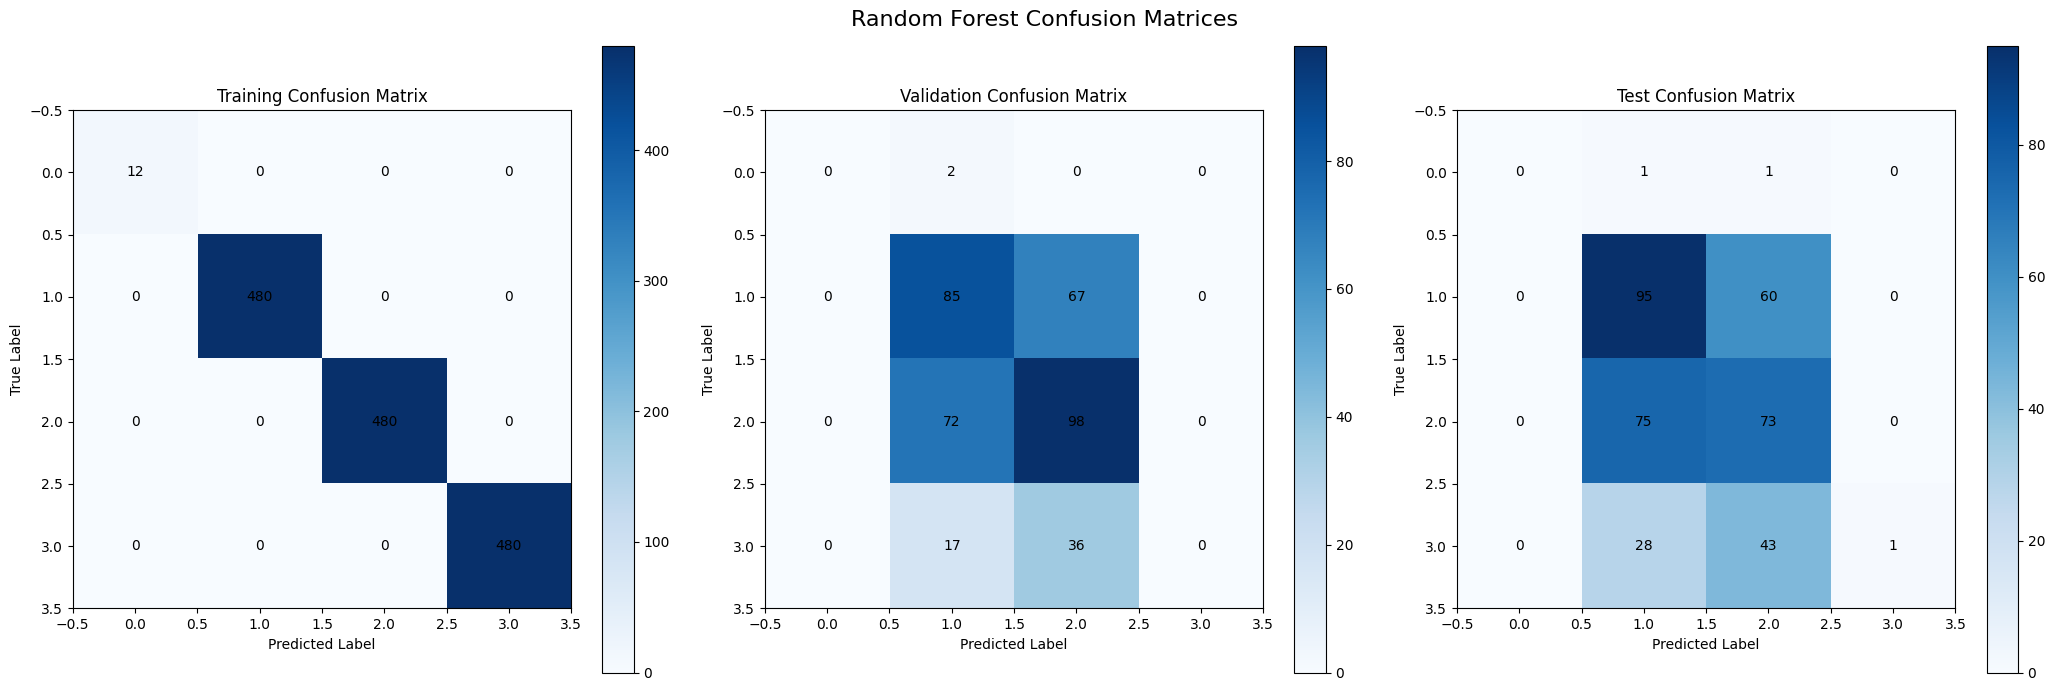

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score

from matplotlib import pyplot as plt

# Inference
print("Running inference...")
train_preds = rf.predict(X_train)
train_probs = rf.predict_proba(X_train)

val_preds = rf.predict(X_val)
val_probs = rf.predict_proba(X_val)

test_preds = rf.predict(X_test)
test_probs = rf.predict_proba(X_test)

# Calculate metrics
def print_metrics(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        unique_classes = np.unique(y_true)
        if len(unique_classes) > 1:
            if y_prob.shape[1] == 2:
                auc = roc_auc_score(y_true, y_prob[:, 1])
            else:
                auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
        else:
            auc = float('nan')
    except ValueError:
        auc = float('nan')
        
    print(f"{name} Metrics:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score (Macro): {f1:.4f}")
    if not np.isnan(auc):
        print(f"  AUROC: {auc:.4f}")
    else:
        print(f"  AUROC: N/A")
    print()

print_metrics("Training", y_train, train_preds, train_probs)
print_metrics("Validation", y_val, val_preds, val_probs)
print_metrics("Test", y_test, test_preds, test_probs)

# Plot confusion matrices
train_cm = confusion_matrix(y_train, train_preds)
val_cm = confusion_matrix(y_val, val_preds)
test_cm = confusion_matrix(y_test, test_preds)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

fig.suptitle("Random Forest Confusion Matrices", fontsize=16)

im1 = axes[0].imshow(train_cm, cmap='Blues')
axes[0].set_title('Training Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
for i in range(train_cm.shape[0]):
    for j in range(train_cm.shape[1]):
        axes[0].text(j, i, str(train_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(val_cm, cmap='Blues')
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
for i in range(val_cm.shape[0]):
    for j in range(val_cm.shape[1]):
        axes[1].text(j, i, str(val_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(test_cm, cmap='Blues')
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')
for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        axes[2].text(j, i, str(test_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [12]:
import joblib

model_path = os.path.join(base_path, "kidney_cancer_rf_model.pkl")
joblib.dump(rf, model_path)
print(f"Random Forest model saved to {model_path}")

Random Forest model saved to /home/petedowney/github/KidneyCancerPrediction/kidney_cancer_rf_model.pkl
